In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import plotly.express as px
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [2]:
#Load the original dataset
df = pd.read_csv("E_Commerce_Data_Set_4034.csv")

# Display basic info about the original dataset
print("Original dataset shape:", df.shape)
print("Original dataset columns:\n", df.columns)
print("\nData types:\n", df.dtypes)

# Create a working copy of the dataset to perform analysis
clean_df = df.copy()

# Check the first few rows of the working dataset
clean_df.head()


Original dataset shape: (800, 4)
Original dataset columns:
 Index(['Genre', 'Age', 'Annual_Income (£K)', 'Spending_Score'], dtype='object')

Data types:
 Genre                  object
Age                   float64
Annual_Income (£K)    float64
Spending_Score        float64
dtype: object


,Genre,Age,Annual_Income (£K),Spending_Score
0,Male,24.0,62.0,13.0
1,Male,52.0,59.0,35.0
2,Female,42.0,31.0,12.0
3,Female,20.0,92.0,41.0
4,Female,30.0,52.0,40.0


In [3]:
# Check basic statistical summary
print("Descriptive statistics:\n")
print(clean_df.describe(include='all'))

#Check missing values in each column
print("\nMissing values per column:\n")
print(clean_df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:\n")
print(clean_df.duplicated().sum())

#Count unique values in each column
print("\nUnique values per column:\n")
print(clean_df.nunique())

#  Display first few rows for manual inspection
print("\nSample data rows:\n")
print(clean_df.head())

Descriptive statistics:

         Genre         Age  Annual_Income (£K)  Spending_Score
count      800  775.000000          781.000000      785.000000
unique       2         NaN                 NaN             NaN
top     Female         NaN                 NaN             NaN
freq       448         NaN                 NaN             NaN
mean       NaN   42.452903           68.288092       31.433121
std        NaN   14.266838           29.571343       18.087046
min        NaN   18.000000           17.000000        1.000000
25%        NaN   29.000000           43.000000       15.000000
50%        NaN   43.000000           67.000000       32.000000
75%        NaN   55.000000           93.000000       46.000000
max        NaN   68.000000          141.000000       67.000000

Missing values per column:

Genre                  0
Age                   25
Annual_Income (£K)    19
Spending_Score        15
dtype: int64

Number of duplicate rows:

252

Unique values per column:

Genre            

In [4]:
# Data Cleaning
clean_df.drop_duplicates(inplace=True)
clean_df.duplicated().sum()
clean_df.isnull().sum()


,0
Genre,0
Age,20
Annual_Income (£K),14
Spending_Score,10


In [5]:
clean_df['Gender'] = clean_df['Genre']

# Encode categorical variables
le = LabelEncoder()
clean_df['Gender_Code'] = le.fit_transform(clean_df['Genre'])
clean_df.drop(columns=['Genre'], inplace=True)

clean_df['Age'] = clean_df['Age'].astype('Int64')

# Convert 'Salary(£)' to float
clean_df['Annual_Income (£K)'] = clean_df['Annual_Income (£K)'].astype(float)

# Display updated data types

print(clean_df.dtypes)

print(clean_df.describe(include='all'))

Age                     Int64
Annual_Income (£K)    float64
Spending_Score        float64
Gender                 object
Gender_Code             int64
dtype: object
              Age  Annual_Income (£K)  Spending_Score  Gender  Gender_Code
count       528.0          534.000000      538.000000     548   548.000000
unique       <NA>                 NaN             NaN       2          NaN
top          <NA>                 NaN             NaN  Female          NaN
freq         <NA>                 NaN             NaN     307          NaN
mean    42.429924           69.086142       30.773234     NaN     0.439781
std     14.212097           29.622327       18.054250     NaN     0.496814
min          18.0           17.000000        1.000000     NaN     0.000000
25%         29.75           46.000000       14.000000     NaN     0.000000
50%          43.0           67.000000       31.000000     NaN     0.000000
75%          55.0           94.000000       46.000000     NaN     1.000000
max        

In [6]:
clean_df.head()

,Age,Annual_Income (£K),Spending_Score,Gender,Gender_Code
0,24,62.0,13.0,Male,1
1,52,59.0,35.0,Male,1
2,42,31.0,12.0,Female,0
3,20,92.0,41.0,Female,0
4,30,52.0,40.0,Female,0


In [7]:
# Columns to check for outliers
numerical_cols = ['Age', 'Annual_Income (£K)', 'Spending_Score']

In [8]:
# Fill Null Value with  Choose 5 closest neighbors
knn_imputer = KNNImputer(n_neighbors=5)
clean_df[numerical_cols] = knn_imputer.fit_transform(clean_df[numerical_cols])
clean_df.isnull().sum()

,0
Age,0
Annual_Income (£K),0
Spending_Score,0
Gender,0
Gender_Code,0


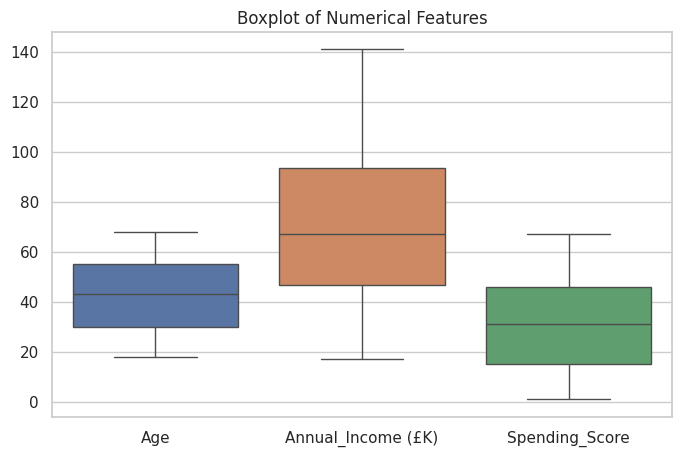

In [9]:
# Boxplot to detect outliers
plt.figure(figsize=(8,5))
sns.boxplot(data=clean_df[numerical_cols])
plt.title('Boxplot of Numerical Features')
plt.show()


In [10]:
# Function to remove outliers using IQR method
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df



# Apply the function
df_no_outliers = remove_outliers_iqr(clean_df, numerical_cols)

# Show change in shape
print("Before:", clean_df.shape)
print("After :", df_no_outliers.shape)

Before: (548, 5)
After : (548, 5)


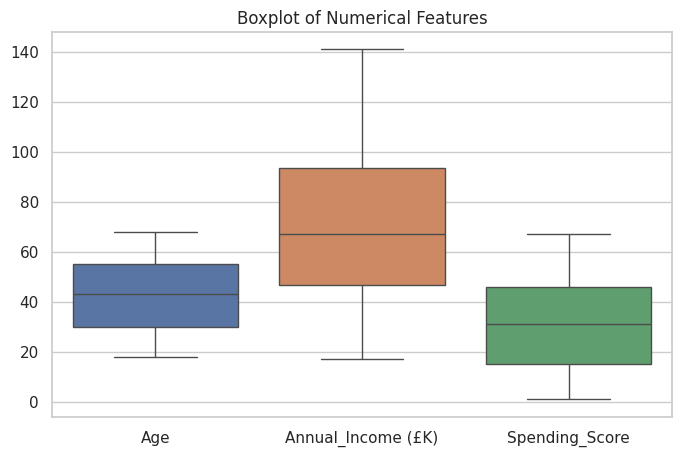

In [11]:
# Boxplot after remove outliers
plt.figure(figsize=(8,5))
sns.boxplot(data=clean_df[numerical_cols])
plt.title('Boxplot of Numerical Features')
plt.show()

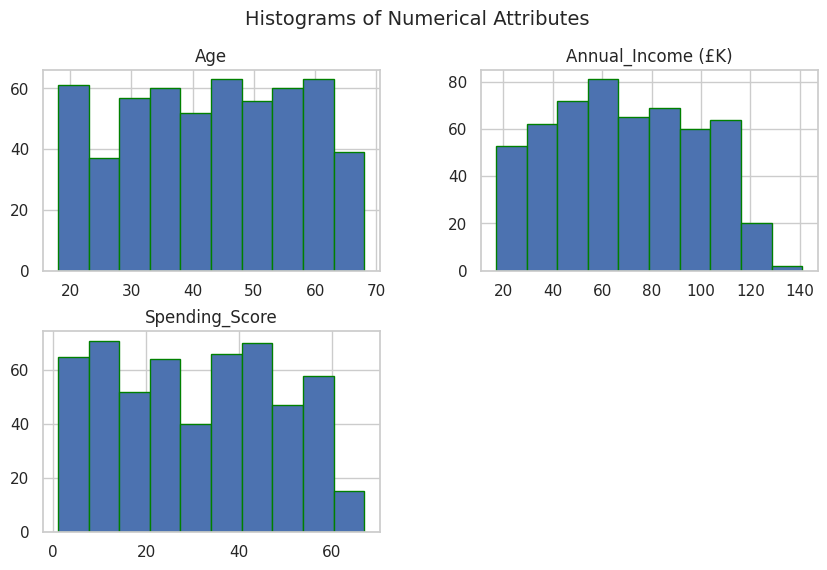

In [12]:
# Visualizing the distribution of numerical attributes
clean_df[numerical_cols].hist(figsize=(10, 6), bins=10, edgecolor='green')
plt.suptitle('Histograms of Numerical Attributes', fontsize=14)
plt.show()

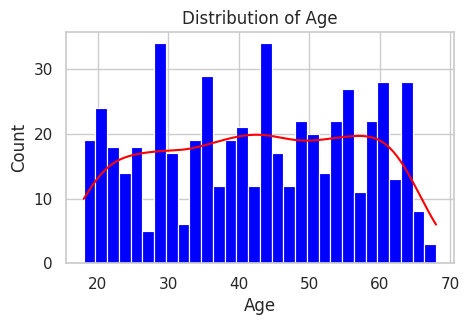

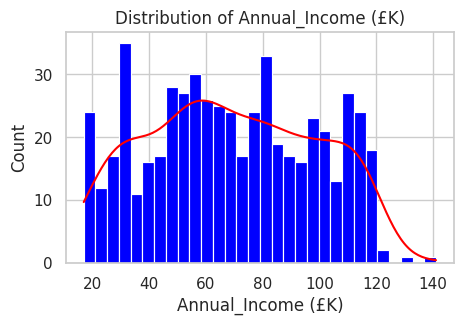

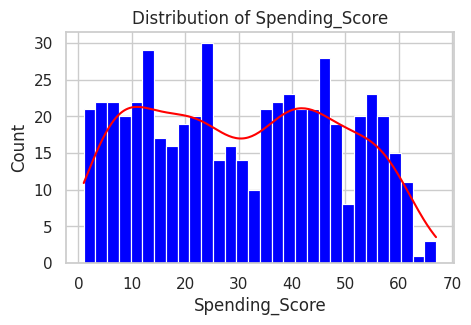

In [13]:
for col in numerical_cols:
    plt.figure(figsize=(5 ,3))
    sns.histplot(clean_df[col], kde=True, bins=30,color='red',facecolor='blue' )
    plt.title(f"Distribution of {col}")
    plt.grid(True)
    plt.show()

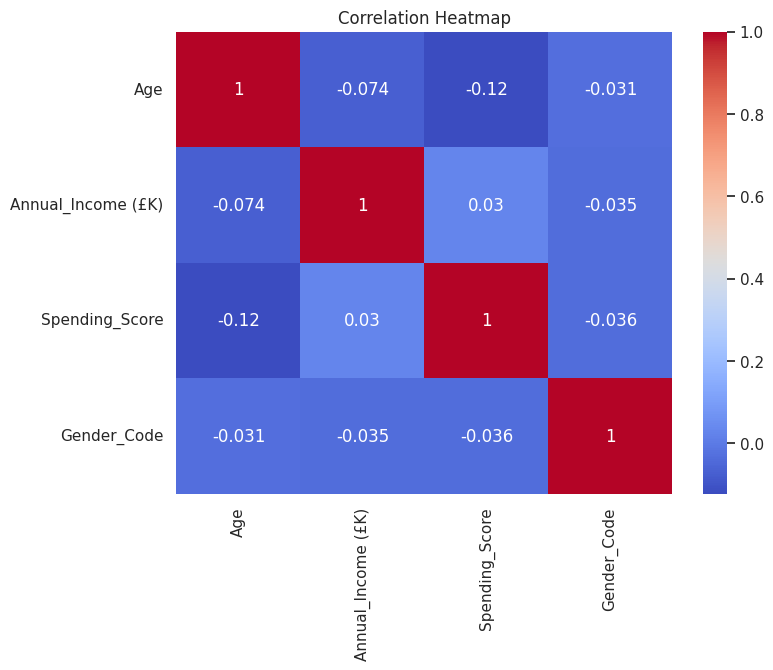

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(clean_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

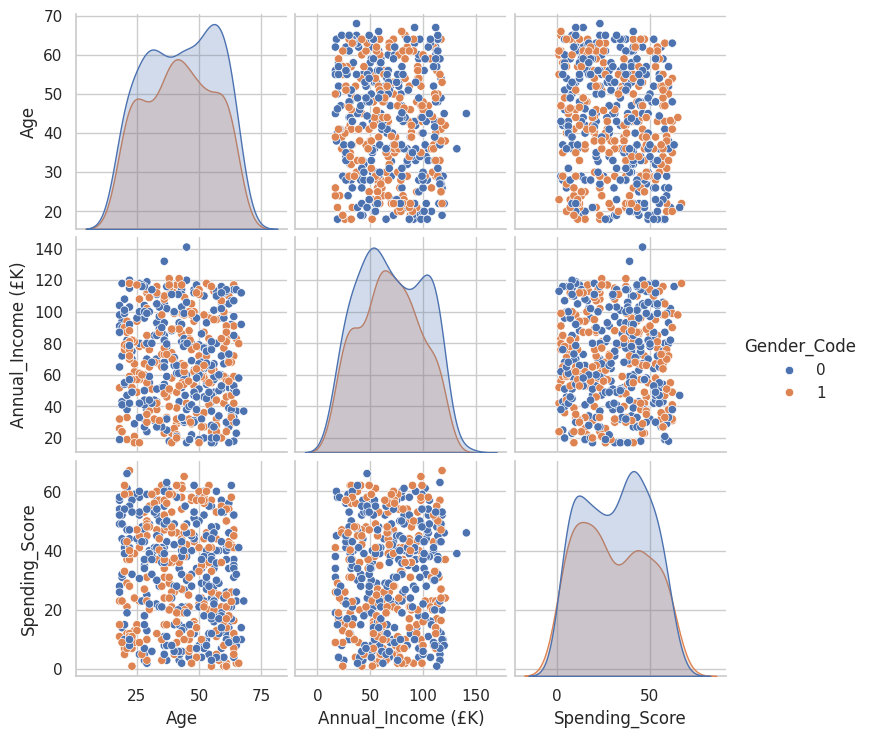

In [15]:
# Pairplot to see relationships between numerical features
sns.pairplot(clean_df, hue='Gender_Code')
plt.show()


In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clean_df[['Age', 'Annual_Income (£K)', 'Spending_Score', 'Gender_Code']])

In [17]:
# linear regression analysis for the relationship between variables
Y1 = clean_df["Spending_Score"]
X1 = clean_df[["Age", "Annual_Income (£K)", "Gender_Code"]]
X1 = sm.add_constant(X1)
X1 = X1.astype(float)
model = sm.OLS(Y1, X1).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Spending_Score   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     3.114
Date:                Mon, 21 Apr 2025   Prob (F-statistic):             0.0259
Time:                        20:59:57   Log-Likelihood:                -2354.1
No. Observations:                 548   AIC:                             4716.
Df Residuals:                     544   BIC:                             4734.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 37.1342      3

### k_means

In [18]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 548 entries, 0 to 799
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 548 non-null    float64
 1   Annual_Income (£K)  548 non-null    float64
 2   Spending_Score      548 non-null    float64
 3   Gender              548 non-null    object 
 4   Gender_Code         548 non-null    int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 25.7+ KB


In [19]:
clean_df.head()

,Age,Annual_Income (£K),Spending_Score,Gender,Gender_Code
0,24.0,62.0,13.0,Male,1
1,52.0,59.0,35.0,Male,1
2,42.0,31.0,12.0,Female,0
3,20.0,92.0,41.0,Female,0
4,30.0,52.0,40.0,Female,0


elbow method

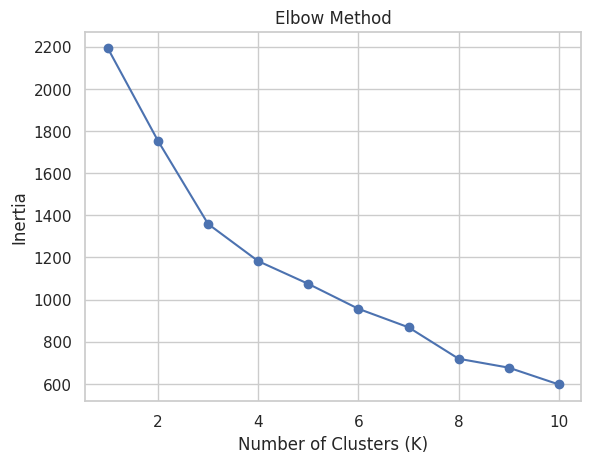

In [20]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()


In [21]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(scaled_data)

# Add cluster labels to the original data
clean_df['Cluster_k'] = kmeans.labels_


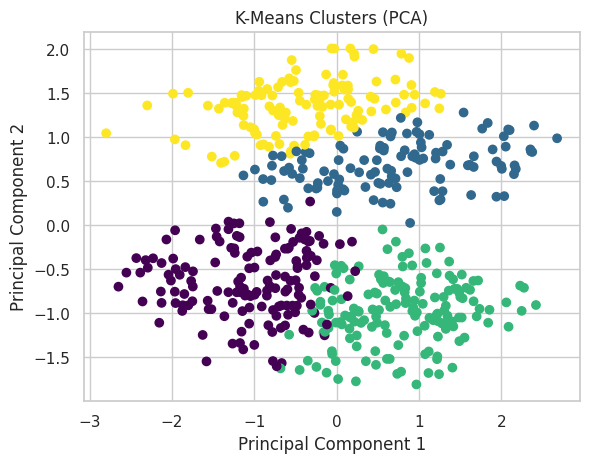

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca_components = pca.fit_transform(scaled_data)

plt.scatter(pca_components[:, 0], pca_components[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title('K-Means Clusters (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [23]:
clean_df.groupby('Cluster_k')[['Age', 'Annual_Income (£K)', 'Spending_Score', 'Gender_Code']].mean()

,Age,Annual_Income (£K),Spending_Score,Gender_Code
Cluster_k,,,,
0,31.183784,81.082432,38.139189,0.0
1,52.665517,77.146552,24.091379,1.0
2,53.650314,59.600000,24.904403,0.0
3,32.027200,59.332800,35.451200,1.0


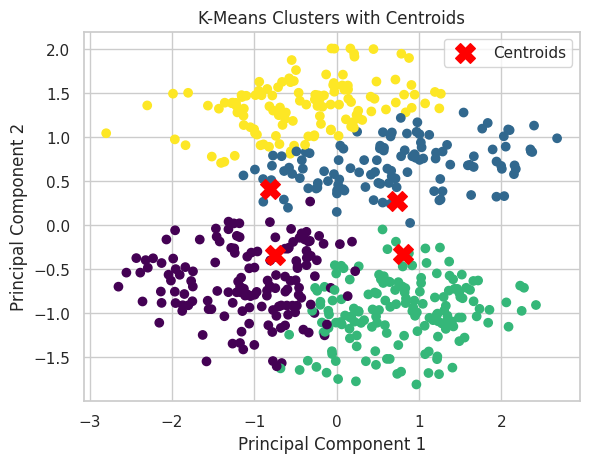

In [24]:
centers = kmeans.cluster_centers_
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200, c='red', label='Centroids')
plt.title('K-Means Clusters with Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


In [25]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(scaled_data, kmeans.labels_)
print(f'Silhouette Score: {sil_score}')


Silhouette Score: 0.252627112440979


*italicized text*### Hierarchical Clustering

In [26]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [27]:
linked = linkage(scaled_data, method='ward')


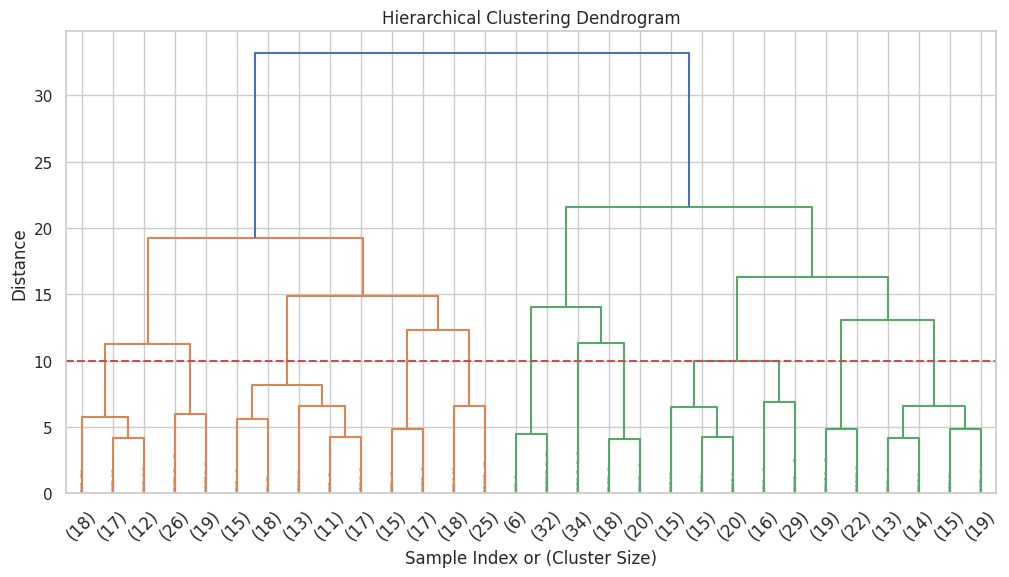

In [28]:
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=45., leaf_font_size=12., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.axhline(y=10, color='r', linestyle='--')  # adjust the height based on the dendrogram
plt.show()


In [29]:
# Assigning 4 clusters
clean_df['Hierarchical_Cluster'] = fcluster(linked, t=4, criterion='maxclust')


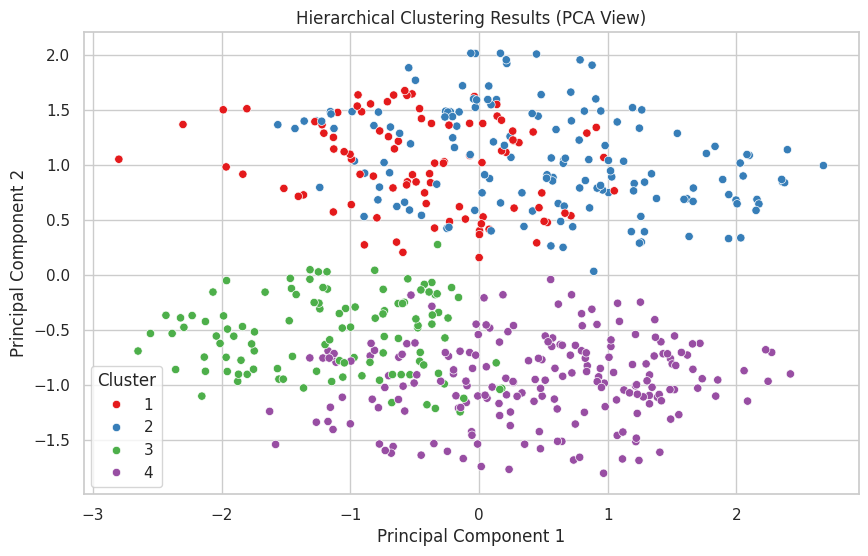

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
components = pca.fit_transform(scaled_data)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=clean_df['Hierarchical_Cluster'], palette='Set1')
plt.title('Hierarchical Clustering Results (PCA View)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


In [31]:
# Define the 'features' variable with the columns you want to analyze
features = ['Age', 'Annual_Income (£K)', 'Spending_Score', 'Gender_Code']  # Replace with your actual features

# Then, use it in the groupby:
cluster_profile = clean_df.groupby('Hierarchical_Cluster')[features].mean()
print(cluster_profile)

                            Age  Annual_Income (£K)  Spending_Score  \
Hierarchical_Cluster                                                  
1                     43.689130           67.389130       49.830435   
2                     40.893960           68.226846       17.728859   
3                     27.718182           80.060000       35.923636   
4                     51.251777           64.314721       28.694416   

                      Gender_Code  
Hierarchical_Cluster               
1                             1.0  
2                             1.0  
3                             0.0  
4                             0.0  


Compare with KMeans

In [32]:
pd.crosstab(clean_df['Cluster_k'], clean_df['Hierarchical_Cluster'])


Hierarchical_Cluster,1,2,3,4
Cluster_k,,,,
0,0,0,108,40
1,31,85,0,0
2,0,0,2,157
3,61,64,0,0


### Agglomerative Clustering

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Assuming 'clean_df' is your DataFrame
agglo = AgglomerativeClustering(n_clusters=4, linkage='ward') # Remove 'affinity'
clean_df['Agglomerative_Cluster'] = agglo.fit_predict(scaled_data)

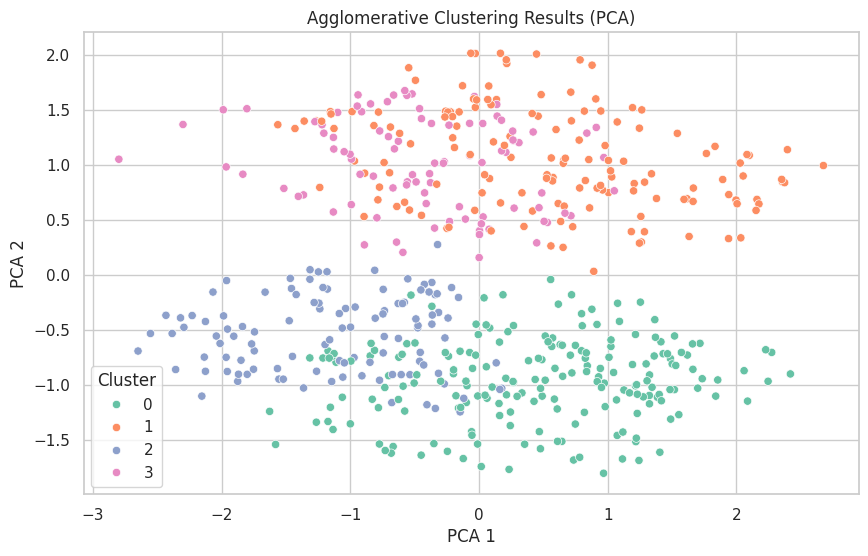

In [35]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=4)
components = pca.fit_transform(scaled_data)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=components[:, 0], y=components[:, 1],
                hue=clean_df['Agglomerative_Cluster'], palette='Set2')
plt.title('Agglomerative Clustering Results (PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()


In [36]:
clean_df.groupby('Agglomerative_Cluster')[features].mean()


,Age,Annual_Income (£K),Spending_Score,Gender_Code
Agglomerative_Cluster,,,,
0,51.251777,64.314721,28.694416,0.0
1,40.893960,68.226846,17.728859,1.0
2,27.718182,80.060000,35.923636,0.0
3,43.689130,67.389130,49.830435,1.0


In [37]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 548 entries, 0 to 799
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    548 non-null    float64
 1   Annual_Income (£K)     548 non-null    float64
 2   Spending_Score         548 non-null    float64
 3   Gender                 548 non-null    object 
 4   Gender_Code            548 non-null    int64  
 5   Cluster_k              548 non-null    int32  
 6   Hierarchical_Cluster   548 non-null    int32  
 7   Agglomerative_Cluster  548 non-null    int64  
dtypes: float64(3), int32(2), int64(2), object(1)
memory usage: 34.2+ KB


# visulization

In [38]:
# Apply PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_data)
clean_df['PCA_1'] = pca_result[:, 0]
clean_df['PCA_2'] = pca_result[:, 1]

In [40]:
import plotly.express as px

fig_kmeans = px.scatter(clean_df, x='PCA_1', y='PCA_2',
                        color=clean_df['Cluster_k'].astype(str),
                        title='KMeans Clustering (PCA View)',
                        hover_data=['Age', 'Annual_Income (£K)', 'Spending_Score', 'Gender_Code'])
fig_kmeans.show()


In [41]:
import plotly.express as px
from sklearn.decomposition import PCA

# Apply PCA (only once)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
clean_df['PCA_1'] = pca_result[:, 0]
clean_df['PCA_2'] = pca_result[:, 1]

#  KMeans Clustering
fig_kmeans = px.scatter(
    clean_df, x='PCA_1', y='PCA_2',
    color=clean_df['Cluster_k'].astype(str),
    title='KMeans Clustering (PCA View)',
    hover_data=['Age', 'Annual_Income (£K)', 'Spending_Score', 'Gender_Code']
)
fig_kmeans.show()

# Hierarchical Clustering
fig_hierarchical = px.scatter(
    clean_df, x='PCA_1', y='PCA_2',
    color=clean_df['Hierarchical_Cluster'].astype(str),
    title='Hierarchical Clustering (PCA View)',
    hover_data=['Age', 'Annual_Income (£K)', 'Spending_Score', 'Gender_Code']
)
fig_hierarchical.show()

#  Agglomerative Clustering
fig_agglomerative = px.scatter(
    clean_df, x='PCA_1', y='PCA_2',
    color=clean_df['Agglomerative_Cluster'].astype(str),
    title='Agglomerative Clustering (PCA View)',
    hover_data=['Age', 'Annual_Income (£K)', 'Spending_Score', 'Gender_Code']
)
fig_agglomerative.show()



In [42]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create subplot grid
fig = make_subplots(rows=1, cols=3, subplot_titles=("KMeans", "Hierarchical", "Agglomerative"))

# Add traces
for i, cluster_label in enumerate(['Cluster_k', 'Hierarchical_Cluster', 'Agglomerative_Cluster']):
    fig.add_trace(go.Scatter(
        x=clean_df['PCA_1'],
        y=clean_df['PCA_2'],
        mode='markers',
        marker=dict(color=clean_df[cluster_label], colorscale='Viridis', showscale=False),
        text=[f'Age: {a}, Income: {i}, Score: {s}' for a, i, s in zip(clean_df['Age'], clean_df['Annual_Income (£K)'], clean_df['Spending_Score'])],
        name=cluster_label
    ), row=1, col=i+1)

fig.update_layout(height=500, width=1400, title_text="Clustering Comparison (PCA Reduced)")
fig.show()


In [43]:
clean_df

,Age,Annual_Income (£K),Spending_Score,Gender,Gender_Code,Cluster_k,Hierarchical_Cluster,Agglomerative_Cluster,PCA_1,PCA_2
0,24.0,62.0,13.0,Male,1,3,2,1,-0.028660,1.519592
1,52.0,59.0,35.0,Male,1,1,2,1,0.575003,0.882649
2,42.0,31.0,12.0,Female,0,2,4,0,1.091283,-0.426001
3,20.0,92.0,41.0,Female,0,0,3,2,-1.838158,-0.473343
4,30.0,52.0,40.0,Female,0,0,3,2,-0.735180,-0.329228
...,...,...,...,...,...,...,...,...,...,...
795,45.2,80.0,19.0,Female,0,2,4,0,0.264335,-0.972250
796,28.0,50.0,34.0,Female,0,0,3,2,-0.594585,-0.264023
797,47.0,99.0,2.0,Male,1,1,2,1,0.859354,0.605842
798,37.0,73.0,56.0,Male,1,3,1,3,-1.048178,1.116470


In [44]:
# Convert gender code to readable label
clean_df['Gender_Code'] = clean_df['Gender_Code'].map({0: 'Female', 1: 'Male'})

In [45]:
# PCA to 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_data)
clean_df['PCA_1'] = pca_result[:, 0]
clean_df['PCA_2'] = pca_result[:, 1]
clean_df['PCA_3'] = pca_result[:, 2]

In [46]:
import plotly.express as px

# Function to create 3D cluster plot
def plot_3d_cluster(df, cluster_col, title):
    fig = px.scatter_3d(df, x='PCA_1', y='PCA_2', z='PCA_3',
                        color=df[cluster_col].astype(str),
                        symbol='Gender_Code', # Changed 'Gender_Label' to 'Gender_Code'
                        hover_data=['Age', 'Annual_Income (£K)', 'Spending_Score'],
                        title=title)

    # Dropdown for gender filter
    fig.update_layout(
        updatemenus=[
            dict(
                buttons=list([
                    dict(label="All",
                         method="update",
                         args=[{"visible": [True]*len(df)}]),
                    dict(label="Male",
                         method="update",
                         args=[{"visible": df['Gender_Code'] == 'Male'}]), # Changed 'Gender_Label' to 'Gender_Code'
                    dict(label="Female",
                         method="update",
                         args=[{"visible": df['Gender_Code'] == 'Female'}]), # Changed 'Gender_Label' to 'Gender_Code'
                ]),
                direction="down",
                showactive=True,
                x=0.1,
                y=1.15,
                xanchor="left",
                yanchor="top"
            )
        ]
    )
    fig.show()

# Plot all 3 cluster types
plot_3d_cluster(clean_df, 'Cluster_k', "KMeans Clustering (3D PCA View)")
plot_3d_cluster(clean_df, 'Hierarchical_Cluster', "Hierarchical Clustering (3D PCA View)")
plot_3d_cluster(clean_df, 'Agglomerative_Cluster', "Agglomerative Clustering (3D PCA View)")

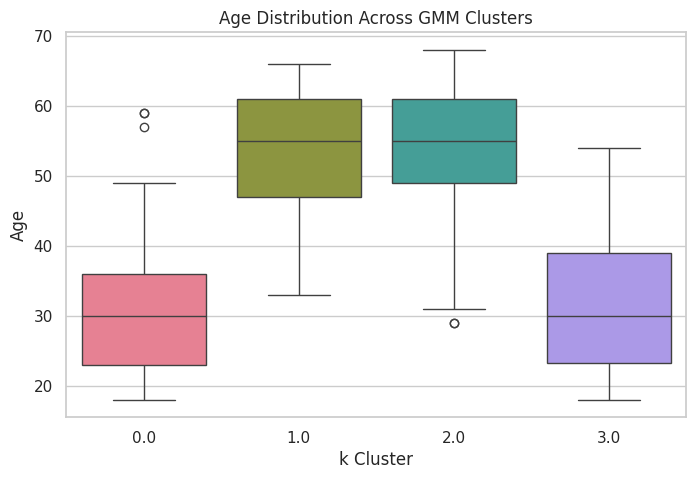

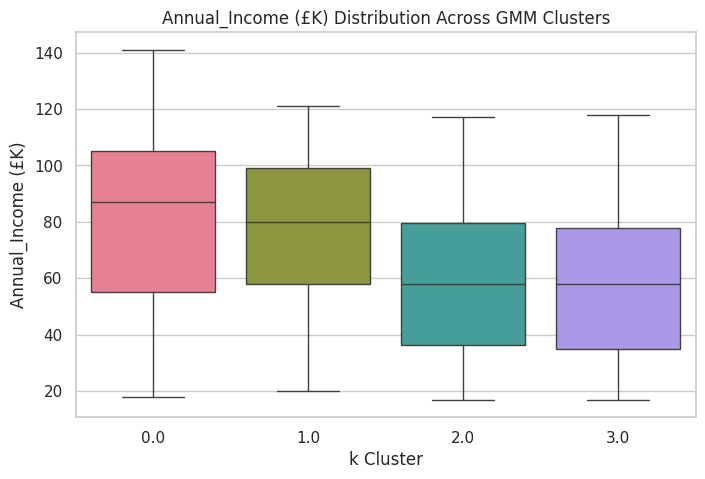

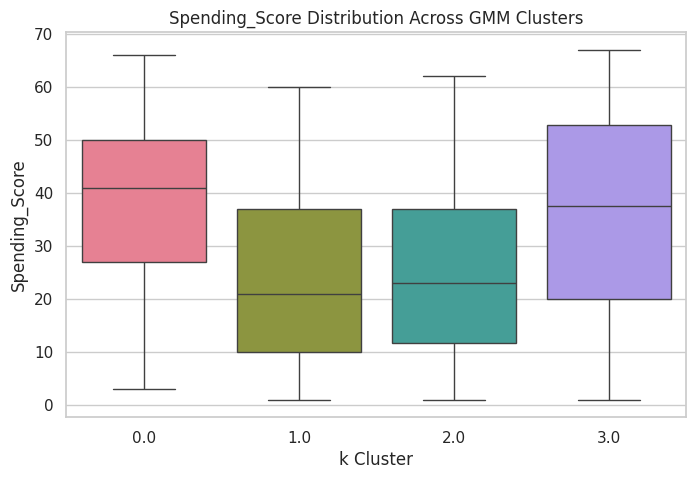

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['Age', 'Annual_Income (£K)', 'Spending_Score']

for feature in features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=clean_df['Cluster_k'], y=df[feature], palette="husl")
    plt.title(f"{feature} Distribution Across GMM Clusters")
    plt.xlabel("k Cluster")
    plt.ylabel(feature)
    plt.show()

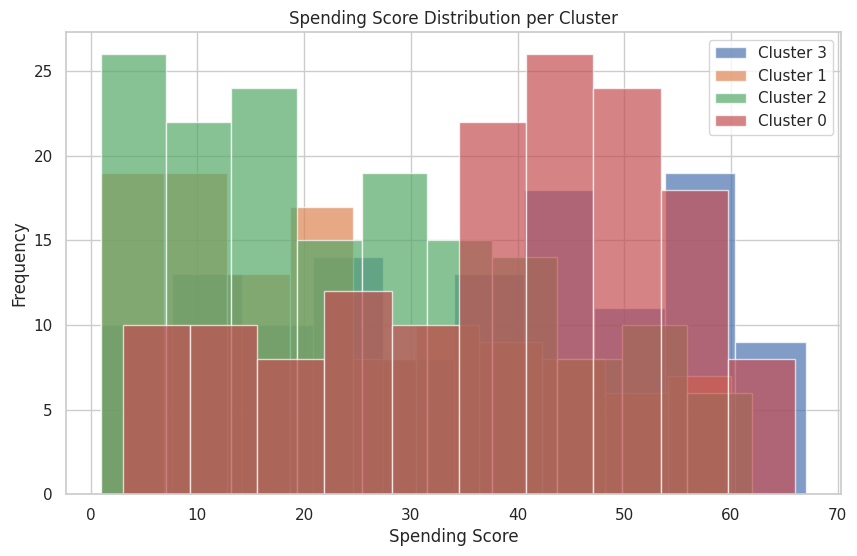

In [48]:
import matplotlib.pyplot as plt

# Assuming 'df' and 'df_pca' are defined from the previous code and 'df' contains 'Cluster_k' and 'Spending_Score'

plt.figure(figsize=(10, 6))

for cluster_label in clean_df['Cluster_k'].unique():
    cluster_data = clean_df[clean_df['Cluster_k'] == cluster_label]
    plt.hist(cluster_data['Spending_Score'], alpha=0.7, label=f'Cluster {cluster_label}')

plt.xlabel('Spending Score')
plt.ylabel('Frequency')
plt.title('Spending Score Distribution per Cluster')
plt.legend()
plt.grid(True)
plt.show()

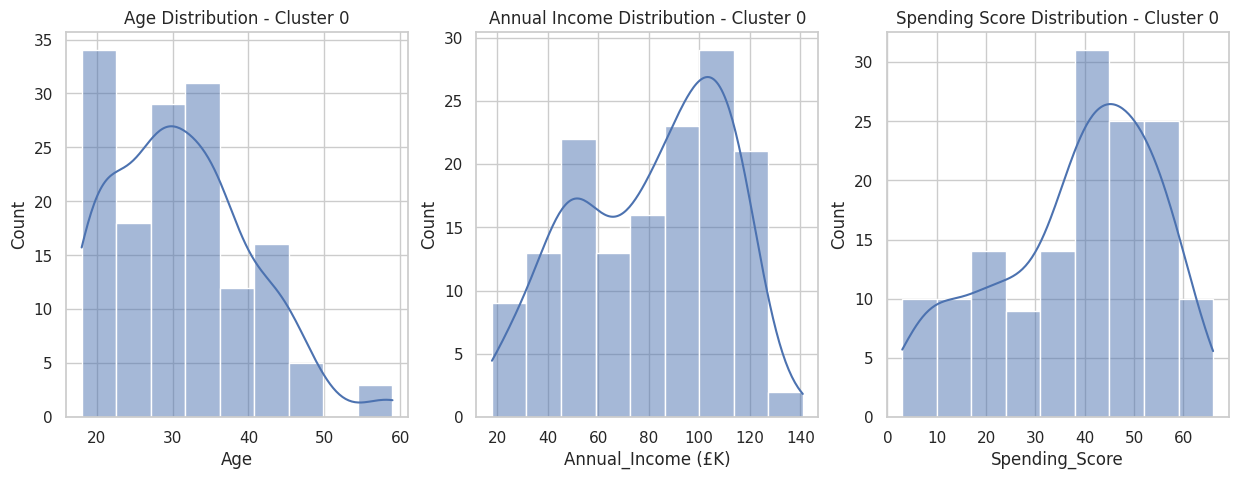

Cluster 0 Statistics:
              Age  Annual_Income (£K)  Spending_Score
count  148.000000          148.000000      148.000000
mean    31.183784           81.082432       38.139189
std      9.086568           29.108373       16.009753
min     18.000000           18.000000        3.000000
25%     23.000000           55.000000       27.500000
50%     30.000000           87.000000       41.000000
75%     36.000000          105.000000       50.000000
max     59.000000          141.000000       66.000000
--------------------


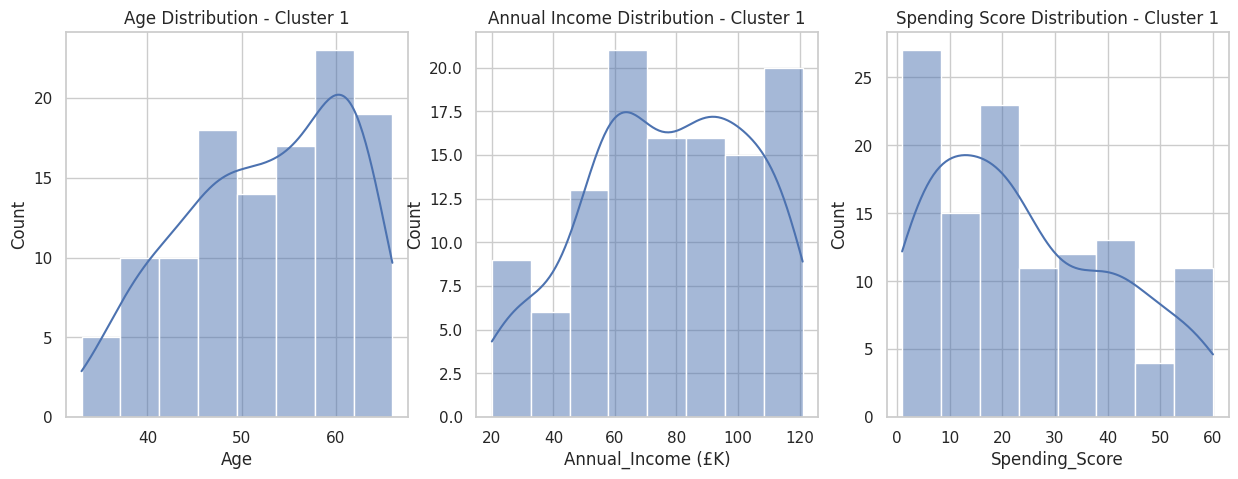

Cluster 1 Statistics:
              Age  Annual_Income (£K)  Spending_Score
count  116.000000          116.000000      116.000000
mean    52.665517           77.146552       24.091379
std      8.614276           27.036238       16.964359
min     33.000000           20.000000        1.000000
25%     46.300000           58.750000       10.000000
50%     54.000000           79.900000       21.000000
75%     61.000000           99.000000       37.100000
max     66.000000          121.000000       60.000000
--------------------


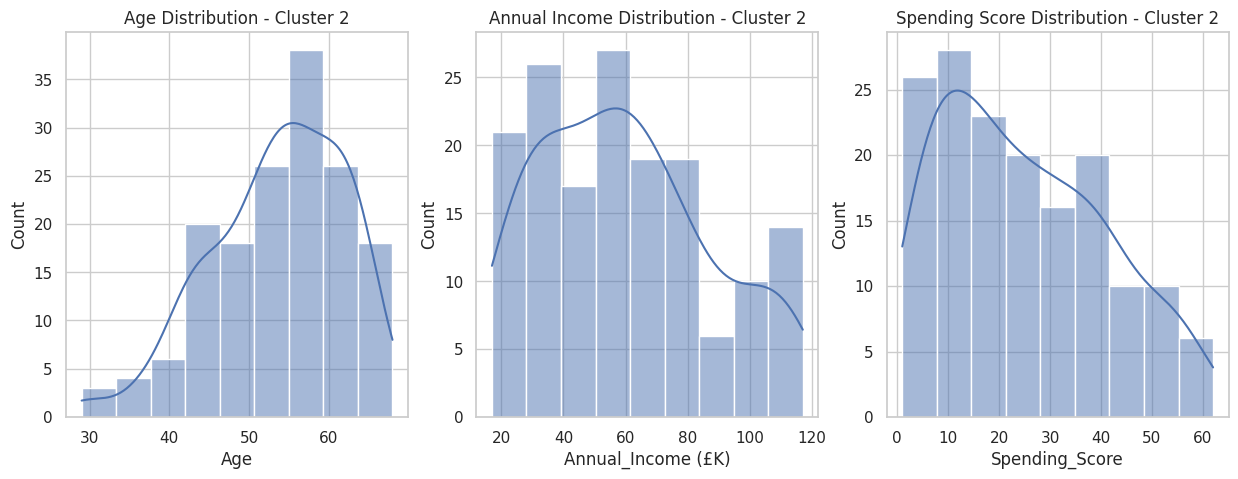

Cluster 2 Statistics:
              Age  Annual_Income (£K)  Spending_Score
count  159.000000          159.000000      159.000000
mean    53.650314           59.600000       24.904403
std      8.295155           27.527027       16.062943
min     29.000000           17.000000        1.000000
25%     48.000000           37.000000       12.000000
50%     55.000000           58.000000       23.000000
75%     60.500000           78.000000       37.000000
max     68.000000          117.000000       62.000000
--------------------


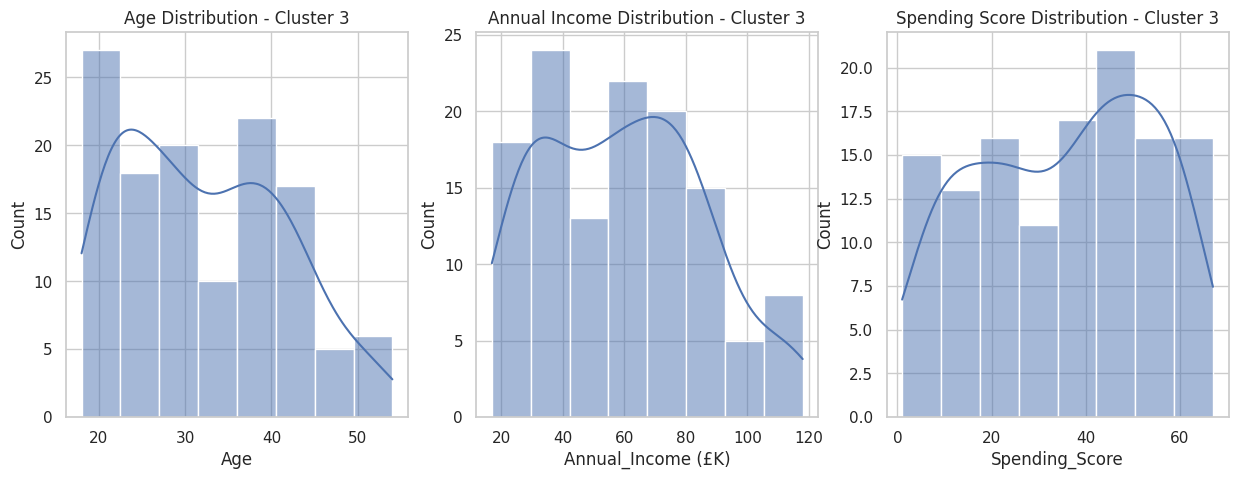

Cluster 3 Statistics:
              Age  Annual_Income (£K)  Spending_Score
count  125.000000           125.00000      125.000000
mean    32.027200            59.33280       35.451200
std      9.359396            26.37769       18.589937
min     18.000000            17.00000        1.000000
25%     24.000000            35.00000       20.000000
50%     30.000000            58.00000       37.000000
75%     39.000000            78.00000       52.000000
max     54.000000           118.00000       67.000000
--------------------


In [49]:

import matplotlib.pyplot as plt
import seaborn as sns

# Group data by cluster
grouped = clean_df.groupby('Cluster_k')

# Iterate through each cluster and create analysis plots
for cluster_label, cluster_data in grouped:
    plt.figure(figsize=(15, 5))  # Adjust figure size as needed

    # Plot Age distribution
    plt.subplot(1, 3, 1)
    sns.histplot(cluster_data['Age'], kde=True)
    plt.title(f'Age Distribution - Cluster {cluster_label}')

    # Plot Annual Income distribution
    plt.subplot(1, 3, 2)
    sns.histplot(cluster_data['Annual_Income (£K)'], kde=True)
    plt.title(f'Annual Income Distribution - Cluster {cluster_label}')

    # Plot Spending Score distribution
    plt.subplot(1, 3, 3)
    sns.histplot(cluster_data['Spending_Score'], kde=True)
    plt.title(f'Spending Score Distribution - Cluster {cluster_label}')

    plt.show() # Show the plot for the current cluster

    # Additional analysis (example: descriptive statistics)
    print(f"Cluster {cluster_label} Statistics:")
    print(cluster_data[['Age', 'Annual_Income (£K)', 'Spending_Score']].describe())
    print("-" * 20)

In [50]:
cluster_means = clean_df.groupby('Cluster_k')[['Annual_Income (£K)', 'Age', 'Spending_Score']].mean()

# Rank clusters based on Spending_Score
cluster_means_ranked = cluster_means.sort_values('Spending_Score', ascending=False)

print("Cluster Means Ranked by Spending Score:")
cluster_means_ranked

Cluster Means Ranked by Spending Score:


,Annual_Income (£K),Age,Spending_Score
Cluster_k,,,
0,81.082432,31.183784,38.139189
3,59.332800,32.027200,35.451200
2,59.600000,53.650314,24.904403
1,77.146552,52.665517,24.091379


In [51]:
clean_df

,Age,Annual_Income (£K),Spending_Score,Gender,Gender_Code,Cluster_k,Hierarchical_Cluster,Agglomerative_Cluster,PCA_1,PCA_2,PCA_3
0,24.0,62.0,13.0,Male,Male,3,2,1,-0.028660,1.519592,0.648704
1,52.0,59.0,35.0,Male,Male,1,2,1,0.575003,0.882649,-0.132906
2,42.0,31.0,12.0,Female,Female,2,4,0,1.091283,-0.426001,-0.685202
3,20.0,92.0,41.0,Female,Female,0,3,2,-1.838158,-0.473343,0.110775
4,30.0,52.0,40.0,Female,Female,0,3,2,-0.735180,-0.329228,-0.958534
...,...,...,...,...,...,...,...,...,...,...,...
795,45.2,80.0,19.0,Female,Female,2,4,0,0.264335,-0.972250,0.433375
796,28.0,50.0,34.0,Female,Female,0,3,2,-0.594585,-0.264023,-0.827503
797,47.0,99.0,2.0,Male,Male,1,2,1,0.859354,0.605842,1.972513
798,37.0,73.0,56.0,Male,Male,3,1,3,-1.048178,1.116470,-0.379967


In [52]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Get number of clusters
cluster_labels = sorted(clean_df['Cluster_k'].unique())
n_clusters = len(cluster_labels)

# Create 3 rows (1 per metric) and N columns (1 per cluster)
fig = make_subplots(
    rows=3, cols=n_clusters,
    subplot_titles=[
        f'Cluster {cl} - Spending Score' for cl in cluster_labels
    ] + [
        f'Cluster {cl} - Age' for cl in cluster_labels
    ] + [
        f'Cluster {cl} - Income' for cl in cluster_labels
    ],
    specs=[
        [{"type": "xy"} for _ in cluster_labels],       # Row 1: Histogram
        [{"type": "xy"} for _ in cluster_labels],       # Row 2: Box
        [{"type": "xy"} for _ in cluster_labels]        # Row 3: Violin
    ],
    vertical_spacing=0.1,
    horizontal_spacing=0.03
)

# Plot per cluster
for idx, cluster_label in enumerate(cluster_labels):
    cluster_data = clean_df[clean_df['Cluster_k'] == cluster_label]
    col = idx + 1

    # Row 1: Spending Score Histogram
    fig.add_trace(
        go.Histogram(
            x=cluster_data['Spending_Score'],
            nbinsx=10,
            marker_color='blue',
            name=f'Cluster {cluster_label}'
        ),
        row=1, col=col
    )

    # Row 2: Age Box
    fig.add_trace(
        go.Box(
            y=cluster_data['Age'],
            name=f'Age {cluster_label}',
            marker_color='green',
            boxmean='sd'
        ),
        row=2, col=col
    )

    # Row 3: Income Violin
    fig.add_trace(
        go.Violin(
            y=cluster_data['Annual_Income (£K)'],
            box_visible=True,
            meanline_visible=True,
            line_color='yellow',
            name=f'Income {cluster_label}'
        ),
        row=3, col=col
    )

# Update layout
fig.update_layout(
    height=1400,
    width=300 * n_clusters,
    title_text='Cluster Comparison Dashboard (Without Gender Pie)',
    showlegend=False
)

# Axis labels for each row
fig.update_yaxes(title_text="Spending Score", row=1, col=1)
fig.update_yaxes(title_text="Age", row=2, col=1)
fig.update_yaxes(title_text="Annual Income (£K)", row=3, col=1)

# Show the figure
fig.show()


In [53]:
# Evaluation of All Clustering Models
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clustering(X, labels, name):
    if len(set(labels)) > 1:
        print(f"\n{name} Clustering Evaluation:")
        print(f"Silhouette Score:        {silhouette_score(X, labels):.3f}")
        print(f"Davies-Bouldin Index:    {davies_bouldin_score(X, labels):.3f}")
        print(f"Calinski-Harabasz Score: {calinski_harabasz_score(X, labels):.3f}")
    else:
        print(f"{name}: Not enough clusters for evaluation.")


evaluate_clustering(scaled_data, clean_df["Cluster_k"], "KMeans")
evaluate_clustering(scaled_data, clean_df["Hierarchical_Cluster"], "Hierarchical")
evaluate_clustering(scaled_data, clean_df["Agglomerative_Cluster"], "Agglomerative")




KMeans Clustering Evaluation:
Silhouette Score:        0.253
Davies-Bouldin Index:    1.534
Calinski-Harabasz Score: 154.786

Hierarchical Clustering Evaluation:
Silhouette Score:        0.236
Davies-Bouldin Index:    1.547
Calinski-Harabasz Score: 143.243

Agglomerative Clustering Evaluation:
Silhouette Score:        0.236
Davies-Bouldin Index:    1.547
Calinski-Harabasz Score: 143.243


ends here

if ur running the below part check the variables and run

In [54]:
clean_df.head()

,Age,Annual_Income (£K),Spending_Score,Gender,Gender_Code,Cluster_k,Hierarchical_Cluster,Agglomerative_Cluster,PCA_1,PCA_2,PCA_3
0,24.0,62.0,13.0,Male,Male,3,2,1,-0.028660,1.519592,0.648704
1,52.0,59.0,35.0,Male,Male,1,2,1,0.575003,0.882649,-0.132906
2,42.0,31.0,12.0,Female,Female,2,4,0,1.091283,-0.426001,-0.685202
3,20.0,92.0,41.0,Female,Female,0,3,2,-1.838158,-0.473343,0.110775
4,30.0,52.0,40.0,Female,Female,0,3,2,-0.735180,-0.329228,-0.958534
